Partie 1
Q1) The analysis shows that Swiggy Instamart leads with the highest total revenue (≈₹76.4M), followed by Blinkit (≈₹72.5M) and Zepto (≈₹70.3M). At the bottom, Jio Mart generates the least revenue (≈₹57.1M), nearly 25% less than the leader.


Q2) The analysis shows that Swiggy Instamart also leads in Average Order Value (AOV ≈ ₹640), followed by Blinkit (≈₹608) and Zepto (≈₹594). Jio Mart has the lowest AOV (≈₹483), which is consistent with its lowest total revenue observed in Q1. This suggests that Swiggy Instamart customers tend to place larger orders, possibly driven by a wider product catalogue or more effective upselling strategies.
Q3)Customer satisfaction varies across platforms. Blinkit stands out with the highest median rating and an unusually wide interquartile range (3–5), indicating a polarized customer base (some customers are very satisfied while others are not.) Dunzo shows the lowest median rating (3) with a narrow box (2–3), suggesting consistently poor satisfaction. Most other platforms share a similar median of 3, with whiskers reaching from 1 to 5, which reflects high variability across all platformsThis highlights a strategic difference between platforms focusing on volume and those prioritizing customer experience
Q4) The relationship between delivery time and delivery partner ratings seem to be  negligible. (correlation de pearson = -0,003)
The correlation between these variables is close to zero. The scatter plot shows that ratings are evenly distributed regardless of delivery duration. That means that customers evaluate delivery partners based on factors other than speed, such as behavior or service quality.
Q5) After filtering the dataset for Swiggy Instamart orders placed in Mumbai by customers aged 30 to 40, the bar chart shows that Dairy is the most popular category with approximately 405 orders, closely followed by Groceries (≈383), Fruits & Vegetables (≈376), and Snacks (≈374). All categories show relatively similar order volumes, suggesting a diversified demand with no single dominant category. This indicates that consumers in this segment primarily purchase essential goods.
Partie 2
q1) The analysis shows that orders with a discount applied have a higher median value (≈₹670) compared to orders without a discount (≈₹450). This suggests that discounts encourage customers to increase their basket size, making promotional strategies financially justified despite the margin reduction they imply.
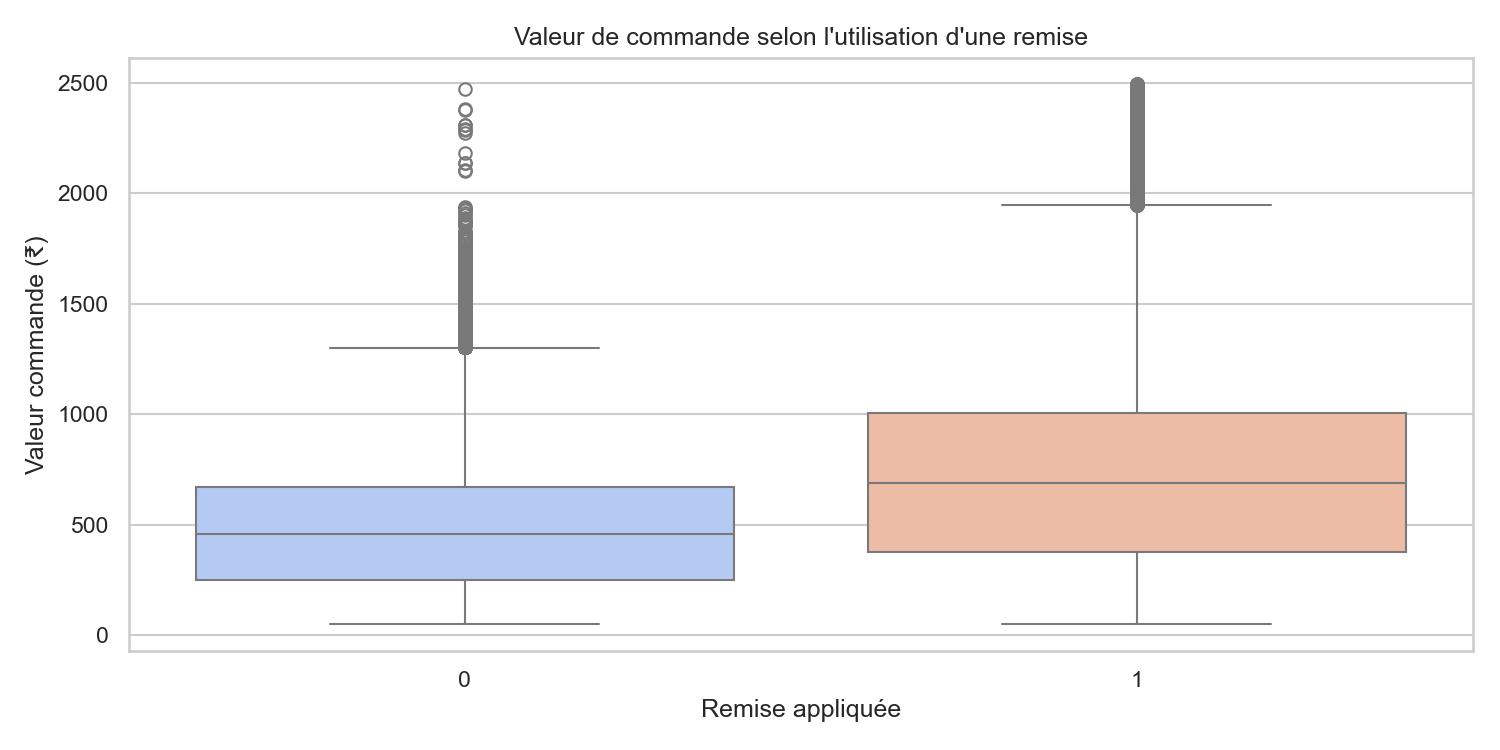

Q2) Based on the four KPIs combined, Bengaluru stands out as the most promising city for expansion: it has the highest customer satisfaction score (3.47), a strong order volume (about 79K orders) and solid total revenue (₹46M). Delhi is also notable for its exceptionally fast delivery time (7.14 min), suggesting highly efficient logistics infrastructure. These cities represent key opportunities for expansion. Conversely, Hyderabad and Haridwar should be deprioritized due to poor customer ratings and slow delivery times
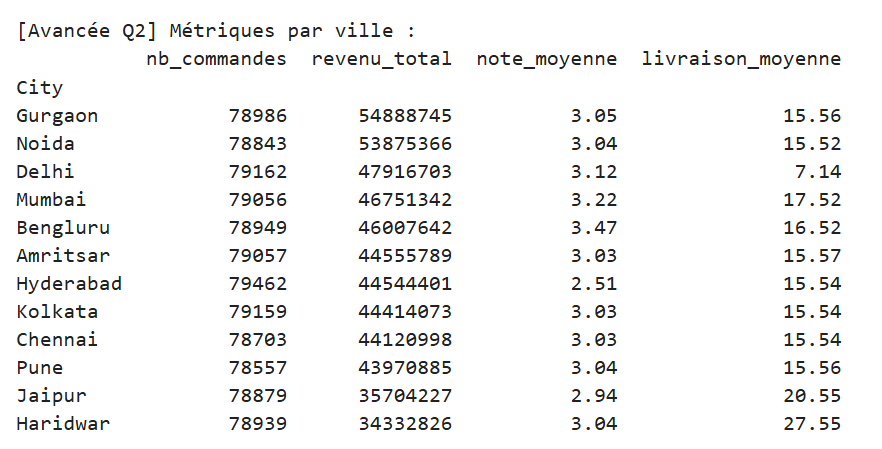



Q3) Zepto seems to show the best operational efficiency, with the fastest average delivery time (9.64 min) and the highest orders-per-minute ratio (12,294)  (nearly twice that of its closest competitor). Blinkit strikes the best balance between speed (15.12 min) and revenue (₹72.5M), making it the most well-rounded platform. Swiggy Instamart leads in total revenue (₹76.4M) despite a slower delivery time, indicating strong commercial performance driven by high order values. At the other end, Jio Mart underperforms on every metric  slowest delivery (23 min), lowest revenue, and fewest orders per minute
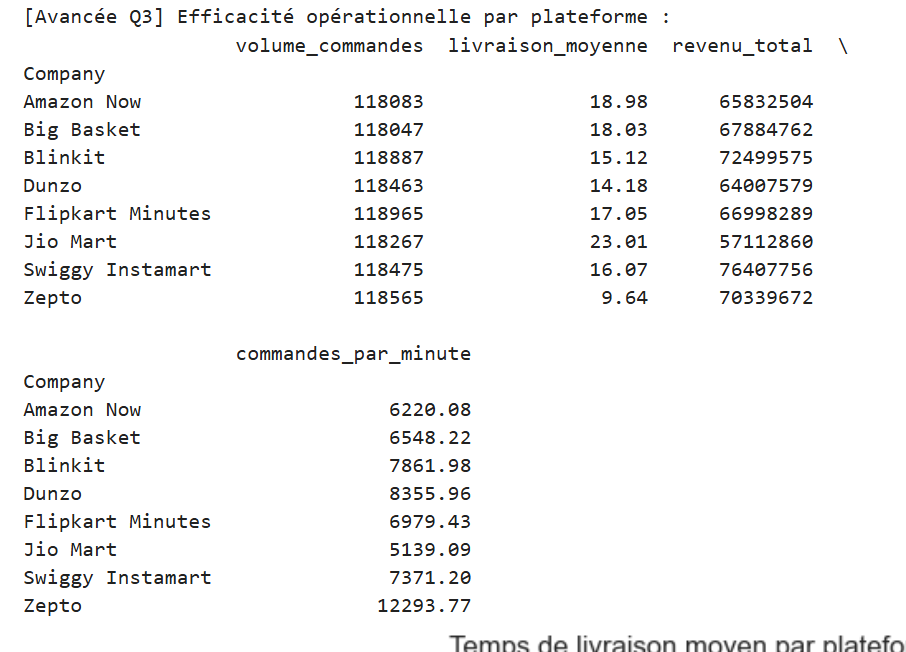





Partie 3
(Oprion 2)
The dataset was split into 80% training data and 20% test data (random_state=42)."
The following explanatory variables were selected: Distance_Km, Items_Count, Order_Value, City, Company, Product_Category, Discount_Applied, and Payment_Method. Categorical variables (City, Company, Product_Category, Payment_Method) were encoded numerically using LabelEncoder before training. Discount_Applied was converted to a binary integer (Yes=1, No=0)."
(The feature importance chart reveals that City (50%) and Company (33%) are  the dominant predictors of delivery time, together accounting for over 80% of the model's predictive power. This makes intuitive business sense: delivery time depends heavily on the geographic infrastructure of each city and the logistical efficiency of each platform. Distance_Km contributes about 15%, which is expected since longer distances naturally require more time. Surprisingly, variables such as Items_Count, Order_Value, Product_Category, Payment_Method, and Discount_Applied have a negligible influence (all below 2%), suggesting that the complexity or value of an order has little impact on how fast it is delivered.")

And, finally, a Random Forest Regressor with 100 estimators was trained on the training set to predict delivery time.

Permorfance measure
The regression model achieved outstanding performance metrics: an RMSE of 1.15 minutes and a MAE of 0.97 minutes indicate that predictions deviate from actual delivery times by less than one minute on average. The R² score of 0.967 confirms that the model explains 96.7% of the variance in delivery time.

Conclusion


This project analyzed quick commerce order data across major Indian cities and platforms. Several key patterns emerged from the analysis. Swiggy Instamart generated the highest total revenue (₹76.4M), while Zepto proved to be the fastest platform with an average delivery time of 9.64 minutes. Bengaluru showed the highest customer satisfaction score (3.47/5), and Delhi demonstrated the most efficient logistics with an average delivery time of only 7.14 minutes. Discounts were found to increase average order value, rising from ₹450 to ₹670 when applied. Finally, the predictive model identified City, Company, and Distance_Km as the three main drivers of delivery time, collectively accounting for over 95% of the model's predictive power.

Concrete recommendations:
First, all platforms should prioritize reducing delivery times, particularly Jio Mart (23 min average) and Haridwar-based operations (27.55 min), as speed is the core value proposition of quick commerce. Second, platforms should consider expanding operations in Bengaluru and Delhi, which combine high satisfaction scores and efficient logistics infrastructure. Third, discount strategies should be maintained and targeted towards larger orders, as they demonstrably increase basket size. Finally, platforms should invest in data collection on contextual variables such as time of day and traffic conditions, which would enable more accurate delivery time predictions and better operational planning."

Limitations of the model used:
This analysis comes with several limitations that must be acknowledged. The dataset appears to be synthetically generated, which significantly inflates model performance metrics — the R² of 0.967 would be unrealistic in a real-world setting. Key operational variables such as weather conditions, traffic, time of day, and rider availability are absent from the dataset, yet are major determinants of delivery time in practice. Furthermore, the discrete nature of rating variables (Customer_Rating, Delivery_Partner_Rating) limited the depth of correlation analyses, as shown in Part 1 Q4. Finally, the label encoding applied to categorical variables such as City and Company introduces an artificial ordinal relationship that may bias the model's interpretation of these features.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, r2_score)
import warnings
warnings.filterwarnings('ignore')

# Style général des graphiques
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv("quick_commerce_india.csv")
# ============================================================
# PARTIE 1 – ANALYSE EXPLORATOIRE (EDA)
# ============================================================
print("\n" + "="*60)
print("PARTIE 1 – ANALYSE EXPLORATOIRE")
print("="*60)

# ----------------------------------------------------------
# Q1 : Quelle plateforme génère le revenu total le plus élevé ?
# ----------------------------------------------------------
revenue_by_platform = df.groupby("Company")["Order_Value"].sum().sort_values(ascending=False)
print("\n[Q1] Revenu total par plateforme :")
print(revenue_by_platform)

plt.figure()
revenue_by_platform.plot(kind="bar", color=["#2196F3", "#FF9800", "#4CAF50"])
plt.title("Revenu total par plateforme")
plt.xlabel("Plateforme")
plt.ylabel("Revenu total (₹)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("q1_revenue_total.png", dpi=150)
plt.show()

# ----------------------------------------------------------
# Q2 : Quelle plateforme a le panier moyen (AOV) le plus élevé ?
# ----------------------------------------------------------
aov_by_platform = df.groupby("Company")["Order_Value"].mean().sort_values(ascending=False)
print("\n[Q2] Panier moyen (AOV) par plateforme :")
print(aov_by_platform.round(2))

plt.figure()
aov_by_platform.plot(kind="bar", color=["#9C27B0", "#E91E63", "#00BCD4"])
plt.title("Panier moyen (AOV) par plateforme")
plt.xlabel("Plateforme")
plt.ylabel("AOV (₹)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("q2_aov.png", dpi=150)
plt.show()

# ----------------------------------------------------------
# Q3 : Comment varie la satisfaction client selon les plateformes ?
# ----------------------------------------------------------
print("\n[Q3] Satisfaction client par plateforme :")
print(df.groupby("Company")["Customer_Rating"].describe().round(2))

plt.figure()
sns.boxplot(data=df, x="Company", y="Customer_Rating", palette="Set2")
plt.title("Distribution des notes clients par plateforme")
plt.xlabel("Plateforme")
plt.ylabel("Note client (1–5)")
plt.tight_layout()
plt.savefig("q3_satisfaction.png", dpi=150)
plt.show()

# ----------------------------------------------------------
# Q4 : Le temps de livraison impacte-t-il la note du livreur ?
# ----------------------------------------------------------
print("\n[Q4] Corrélation temps de livraison / note livreur :")
corr = df["Delivery_Time_Min"].corr(df["Delivery_Partner_Rating"])
print(f"Corrélation de Pearson : {corr:.3f}")

plt.figure()
sns.scatterplot(data=df, x="Delivery_Time_Min", y="Delivery_Partner_Rating",
                alpha=0.4, hue="Company")
# Ligne de tendance
m, b = np.polyfit(df["Delivery_Time_Min"], df["Delivery_Partner_Rating"], 1)
x_line = np.linspace(df["Delivery_Time_Min"].min(), df["Delivery_Time_Min"].max(), 100)
plt.plot(x_line, m * x_line + b, color="red", linewidth=2, label="Tendance")
plt.title("Temps de livraison vs Note livreur")
plt.xlabel("Temps de livraison (min)")
plt.ylabel("Note livreur (1–5)")
plt.legend()
plt.tight_layout()
plt.savefig("q4_scatter.png", dpi=150)
plt.show()

# ----------------------------------------------------------
# Q5 : Catégorie la plus populaire sur Swiggy Instamart,
#       clients 30–40 ans, à Mumbai
# ----------------------------------------------------------
filtre = (
    (df["Company"] == "Swiggy Instamart") &
    (df["City"] == "Mumbai") &
    (df["Customer_Age"] >= 30) &
    (df["Customer_Age"] <= 40)
)
subset = df[filtre]
top_category = subset["Product_Category"].value_counts()
print("\n[Q5] Catégories populaires – Swiggy Instamart, Mumbai, 30–40 ans :")
print(top_category)

plt.figure()
top_category.plot(kind="bar", color="#FF5722")
plt.title("Catégories populaires – Swiggy Instamart | Mumbai | 30–40 ans")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de commandes")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("q5_category.png", dpi=150)
plt.show()


# ============================================================
# PARTIE 2 – KPIs ET ANALYSE BUSINESS
# ============================================================

# KPI 1 : Revenu total par plateforme (déjà calculé en Q1)

# KPI 2 : Nombre de commandes par ville
orders_per_city = df["City"].value_counts()
print("\n[KPI] Nombre de commandes par ville :")
print(orders_per_city)

plt.figure()
orders_per_city.plot(kind="bar", color="#607D8B")
plt.title("Nombre de commandes par ville")
plt.xlabel("Ville")
plt.ylabel("Nombre de commandes")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("kpi_orders_city.png", dpi=150)
plt.show()

# KPI 3 : Temps de livraison moyen par plateforme
avg_delivery = df.groupby("Company")["Delivery_Time_Min"].mean().sort_values()
print("\n[KPI] Temps de livraison moyen par plateforme :")
print(avg_delivery.round(2))

# KPI 4 : Taux d'utilisation des réductions
discount_rate = df["Discount_Applied"].value_counts(normalize=True) * 100
print("\n[KPI] Taux d'utilisation des réductions :")
print(discount_rate.round(2))

# KPI 5 : Note client moyenne par plateforme
avg_rating = df.groupby("Company")["Customer_Rating"].mean()
print("\n[KPI] Note client moyenne par plateforme :")
print(avg_rating.round(2))

# ----------------------------------------------------------
# Q avancée 1 : Les remises augmentent-elles le volume de commande ?
# ----------------------------------------------------------
print("\n[Avancée Q1] Impact des remises sur la valeur des commandes :")
discount_impact = df.groupby("Discount_Applied")["Order_Value"].agg(["mean", "count"])
discount_impact.columns = ["Valeur moyenne (₹)", "Nombre de commandes"]
print(discount_impact.round(2))

plt.figure()
sns.boxplot(data=df, x="Discount_Applied", y="Order_Value", palette="coolwarm")
plt.title("Valeur de commande selon l'utilisation d'une remise")
plt.xlabel("Remise appliquée")
plt.ylabel("Valeur commande (₹)")
plt.tight_layout()
plt.savefig("advanced_q1_discount.png", dpi=150)
plt.show()

# ----------------------------------------------------------
# Q avancée 2 : Villes les plus prometteuses pour l'expansion ?
# ----------------------------------------------------------
city_metrics = df.groupby("City").agg(
    nb_commandes=("Order_ID", "count"),
    revenu_total=("Order_Value", "sum"),
    note_moyenne=("Customer_Rating", "mean"),
    livraison_moyenne=("Delivery_Time_Min", "mean")
).sort_values("revenu_total", ascending=False)
print("\n[Avancée Q2] Métriques par ville :")
print(city_metrics.round(2))

# ----------------------------------------------------------
# Q avancée 3 : Quelle entreprise a la meilleure efficacité opérationnelle ?
# ----------------------------------------------------------
efficiency = df.groupby("Company").agg(
    volume_commandes=("Order_ID", "count"),
    livraison_moyenne=("Delivery_Time_Min", "mean"),
    revenu_total=("Order_Value", "sum")
)
efficiency["commandes_par_minute"] = efficiency["volume_commandes"] / efficiency["livraison_moyenne"]
print("\n[Avancée Q3] Efficacité opérationnelle par plateforme :")
print(efficiency.round(2))

plt.figure(figsize=(8, 5))
sns.barplot(data=efficiency.reset_index(),
            x="Company", y="livraison_moyenne", palette="viridis")
plt.title("Temps de livraison moyen par plateforme")
plt.xlabel("Plateforme")
plt.ylabel("Temps moyen (min)")
plt.tight_layout()
plt.savefig("advanced_q3_efficiency.png", dpi=150)
plt.show()


# ============================================================
# PARTIE 3 – MODÉLISATION PRÉDICTIVE
# ============================================================
# ----------------------------------------------------------
# OPTION 2 : Prédiction du temps de livraison (régression)
# ----------------------------------------------------------
print("\n--- Option 2 : Prédiction du temps de livraison ---")

features_reg = ["Distance_Km", "Items_Count", "Order_Value",
                "City", "Company", "Product_Category",
                "Discount_Applied", "Payment_Method"]

df_reg = df.copy()

# Encodage des variables catégorielles
le = LabelEncoder()
cat_cols = ["City", "Company", "Product_Category", "Payment_Method"]
for col in cat_cols:
    df_reg[col] = le.fit_transform(df_reg[col].astype(str))

if df_reg["Discount_Applied"].dtype == object:
    df_reg["Discount_Applied"] = (df_reg["Discount_Applied"] == "Yes").astype(int)

X_reg = df_reg[features_reg]
y_reg = df_reg["Delivery_Time_Min"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Modèle : Random Forest Regressor
reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train_r, y_train_r)
y_pred_r = reg.predict(X_test_r)

mse  = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_r, y_pred_r)
r2   = r2_score(y_test_r, y_pred_r)

print(f"\nPerformances du modèle de régression :")
print(f"  MSE  : {mse:.2f}")
print(f"  RMSE : {rmse:.2f} min")
print(f"  MAE  : {mae:.2f} min")
print(f"  R²   : {r2:.3f}")

# Graphique valeurs réelles vs prédites
plt.figure()
plt.scatter(y_test_r, y_pred_r, alpha=0.3, color="#26A69A")
plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()], 'r--', linewidth=2)
plt.xlabel("Valeurs réelles (min)")
plt.ylabel("Valeurs prédites (min)")
plt.title("Temps de livraison : réel vs prédit")
plt.tight_layout()
plt.savefig("option2_regression_plot.png", dpi=150)
plt.show()

# Importance des variables
importances_r = pd.Series(reg.feature_importances_, index=features_reg).sort_values()
plt.figure()
importances_r.plot(kind="barh", color="#EF5350")
plt.title("Importance des variables – Temps de livraison")
plt.tight_layout()
plt.savefig("option2_feature_importance.png", dpi=150)
plt.show()




FileNotFoundError: [Errno 2] No such file or directory: 'quick_commerce_india.csv'